---
title: "SARIMAX (Covid, Unemployment)"
format: html
number-sections: true
jupyter: python3
python: ~/venv/bin/python3
---

Load in Python libraries.

In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings('ignore')

Load in Data. Impute missing values.

In [233]:
# crime 
crime = pd.read_csv("rms_crime_incidents.csv")

# unemployment
unemployment = pd.read_csv('unemployment_wayne_county.csv')

# missing value
missing = unemployment.index[unemployment['Value'] == '-'][0]
before_missing = unemployment['Value'][missing - 1]
after_missing =  unemployment['Value'][missing + 1]
avg = (pd.to_numeric(before_missing) + pd.to_numeric(after_missing)) / 2
unemployment['Value'] = unemployment['Value'].replace('-', avg)
unemployment['Value'] = pd.to_numeric(unemployment['Value'])

Crime data cleaning.

In [234]:
crime['incident_occurred_at'] = pd.to_datetime(crime['incident_occurred_at'])

# monthly period
crime['Month'] = crime['incident_occurred_at'].dt.to_period('M')

# aggregate counts over each month and year starting from 2017
crime_monthly = crime.groupby('Month').size().reset_index(name='Incidents')
crime_monthly['Month'] = crime_monthly['Month'].dt.to_timestamp()
crime_monthly = crime_monthly[crime_monthly['Month'].dt.year >= 2017]

# log transform crime
crime_monthly['log_Incidents'] = np.log(crime_monthly['Incidents']) 

Unemployment data cleaning.

In [235]:
unemployment['Label'] =  pd.to_datetime(unemployment['Label'])
unemployment['Label'] = unemployment['Label'].dt.to_period('M')
unemployment['Label'] = unemployment['Label'].dt.to_timestamp()
unemployment = unemployment[unemployment['Label'].dt.year >= 2017]
unemployment['log_Rate'] = np.log(unemployment['Value']) #not used

Covid labels.

In [236]:
edges = [pd.Timestamp("2017-01-01"),pd.Timestamp("2020-03-01",), pd.Timestamp("2022-07-01"), pd.Timestamp("2026-01-01")] #since unemployment limited to 2025

labels = ["pre", "during", "post"]

crime_monthly["covid"] = pd.cut(crime_monthly["Month"], bins=edges, labels=labels, right=False)
crime_monthly = crime_monthly.dropna()
unemployment["covid"] = pd.cut(unemployment["Label"], bins=edges, labels=labels, right=False)

# Unemployment and covid

Exogenous dataframe with unemployment and covid

In [237]:
covid_dummy = pd.get_dummies(crime_monthly["covid"], drop_first=True).astype(float)

covid_dummy_during = covid_dummy['during'].reset_index(drop=True)
covid_dummy_post   = covid_dummy['post'].reset_index(drop=True)

no_of_incidents = crime_monthly['log_Incidents'].reset_index(drop=True)
unemployment_values = unemployment['Value'].reset_index(drop=True)

exog_vars = pd.concat([covid_dummy[['during','post']].reset_index(drop=True),
unemployment_values.reset_index(drop=True)],axis=1)

exog_vars.columns = ['covid_during', 'covid_post', 'unemployment']


# Checks to see if indexing was correct
# covid_dummy_during.index
# covid_dummy_post.index
# unemployment_values.index

print(exog_vars.isna().sum())
print(no_of_incidents.isna().sum())

len(no_of_incidents)
len(exog_vars)

print(exog_vars['unemployment'].isna().sum())
print(unemployment_values.isna().sum())
print(covid_dummy_during.index.equals(unemployment_values.index))

covid_during    0
covid_post      0
unemployment    0
dtype: int64
0
0
0
True


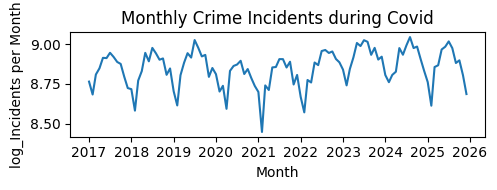

In [238]:
#| fig-cap: "Time plot of log_Incidents per Month"

# Plot
plt.figure(figsize=(5, 2))
plt.title("Monthly Crime Incidents during Covid")
plt.plot(crime_monthly['Month'], crime_monthly['log_Incidents'], '-')
plt.xlabel('Month')
plt.ylabel('log_Incidents per Month')
plt.tight_layout()
plt.show()

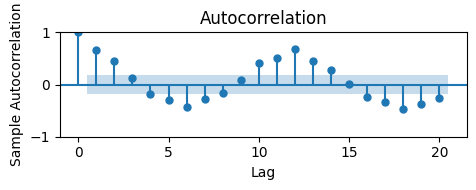

In [239]:
#| label: fig-acf-incidents-during
#| fig-cap: "Sample Autocorrelation function of log_Incidents"

fig, ax = plt.subplots(figsize=(5, 2))
plot_acf(crime_monthly['log_Incidents'], ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

## Modeling with linear Trend

In [240]:
def sarima_aic_table(data, p_max, q_max, P_max, Q_max, m):
    results = []
    # Iterate through all combinations
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            for P in range(P_max + 1):
                for Q in range(Q_max + 1):
                    try:
                        model = SARIMAX(data, order=(p,0,q), trend='t',
                        seasonal_order=(P, 0, Q, m), exog = exog_vars)
                        results_fit = model.fit(disp=False)
                        results.append([p, q, P, Q, results_fit.aic])
                    except:
                        results.append([p, q, P, Q, np.nan])
                        
    # Create DataFrame
    df = pd.DataFrame(results, columns=['AR(p)', 'MA(q)', 'SAR(P)', 'SMA(Q)', 'AIC'])
    df.sort_values(by='AIC')
    # Sort by AIC ascending
    return df.sort_values(by='AIC')

sarima_results = sarima_aic_table(no_of_incidents, 2, 2, 2, 2, 12)


In [241]:
sarima_results.head(10)

,AR(p),MA(q),SAR(P),SMA(Q),AIC
66,2,1,1,0,-260.576683
60,2,0,2,0,-258.655431
34,1,0,2,1,-253.044239
30,1,0,1,0,-244.710757
69,2,1,2,0,-236.413932
64,2,1,0,1,-208.809799
73,2,2,0,1,-208.452479
68,2,1,1,2,-204.690460
65,2,1,0,2,-192.368939
72,2,2,0,0,-180.530259


## After log transformation

Lower AIC than our chosen model: 2111 has good roots BUT the seasonal AR and MA terms are insignificant.
Higher AIC than our chosen model: 1201 has good roots BUT the seasonal MA terms are insignificant.

In [242]:
model = SARIMAX(no_of_incidents, order=(1, 0, 1), trend='t', exog = exog_vars, seasonal_order=(1, 0, 0, 12)).fit()

print(model.summary().tables[1])
ar_roots = model.arroots
print("Magnitude of AR roots:", np.abs(ar_roots))
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

ma_roots = model.maroots
print("Magnitude of MA roots:", np.abs(ma_roots))
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
drift            0.0018      0.001      2.389      0.017       0.000       0.003
covid_during     0.7105      0.080      8.845      0.000       0.553       0.868
covid_post       0.8205      0.767      1.070      0.285      -0.683       2.324
unemployment     0.0186      0.009      2.042      0.041       0.001       0.037
ar.L1            0.9802      0.007    150.367      0.000       0.967       0.993
ma.L1            0.5676      0.090      6.314      0.000       0.391       0.744
ar.S.L12         0.1763      0.080      2.191      0.028       0.019       0.334
sigma2           0.0252      0.005      4.879      0.000       0.015       0.035
Magnitude of AR roots: [1.1556276  1.1556276  1.1556276  1.1556276  1.1556276  1.1556276
 1.1556276  1.1556276  1.1556276  1.1556276  1.1556276  1.02016298
 1.1556276 ]
Magnitude of AR roots

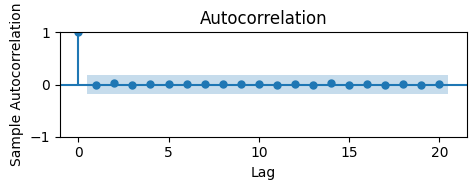

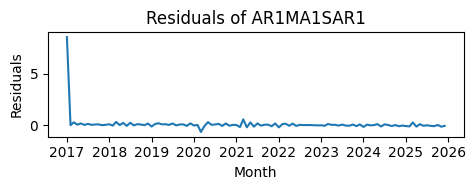

In [243]:
fig, ax = plt.subplots(figsize=(5, 2))
plot_acf(model.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5, 2))
plt.title("Residuals of AR1MA1SAR1")
plt.plot(crime_monthly['Month'], model.resid, '-')
plt.xlabel('Month')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

## Modeling with constant mean (for comparison)

In [ ]:
def sarima_aic_table(data, p_max, q_max, P_max, Q_max, m):
    results = []
    # Iterate through all combinations
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            for P in range(P_max + 1):
                for Q in range(Q_max + 1):
                    try:
                        model = SARIMAX(data, order=(p,0,q), trend='c',
                        seasonal_order=(P, 0, Q, m), exog = exog_vars)
                        results_fit = model.fit(disp=False)
                        results.append([p, q, P, Q, results_fit.aic])
                    except:
                        results.append([p, q, P, Q, np.nan])
                        
    # Create DataFrame
    df = pd.DataFrame(results, columns=['AR(p)', 'MA(q)', 'SAR(P)', 'SMA(Q)', 'AIC'])
    df.sort_values(by='AIC')
    # Sort by AIC ascending
    return df.sort_values(by='AIC')

sarima_results_c = sarima_aic_table(no_of_incidents, 2, 2, 2, 2, 12)

In [ ]:
sarima_results_c.head(30)


,AR(p),MA(q),SAR(P),SMA(Q),AIC
24,0,2,2,0,-314.740364
21,0,2,1,0,-305.165662
25,0,2,2,1,-302.651128
62,2,0,2,2,-302.561951
6,0,0,2,0,-297.319835
51,1,2,2,0,-296.915562
61,2,0,2,1,-295.713575
3,0,0,1,0,-295.685778
22,0,2,1,1,-295.135879
7,0,0,2,1,-294.683216


None of these work well (constant mean, no differencing). Example below.

In [246]:
modelc = SARIMAX(no_of_incidents, order=(1, 0, 1), trend='c', exog = exog_vars,seasonal_order=(0, 0, 1, 12)).fit()

print(modelc.summary().tables[1]) # not enough evidence for covid_during or unemployment

ar_roots = modelc.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) # Possibly too close to boundary. 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

ma_roots = modelc.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) # Possibly too close to boundary. 
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept        0.3094      0.554      0.558      0.577      -0.777       1.396
covid_during    -0.1347      0.047     -2.878      0.004      -0.226      -0.043
covid_post      -0.0773      0.162     -0.476      0.634      -0.395       0.241
unemployment    -0.0053      0.003     -1.746      0.081      -0.011       0.001
ar.L1            0.9653      0.062     15.603      0.000       0.844       1.087
ma.L1           -0.2538      0.109     -2.336      0.019      -0.467      -0.041
ma.S.L12         0.5387      0.120      4.502      0.000       0.304       0.773
sigma2           0.0051      0.001      7.150      0.000       0.004       0.007
Magnitude of AR roots: [1.03598247]
Magnitude of AR roots > 1.1: [False]
Magnitude of MA roots: [1.05289422 1.05289422 1.05289422 1.05289422 1.05289422 1.05289422
 1.05289422 1.05289422 1.05

# Covid only

## Modeling with linear trend

In [ ]:
exog_covid = exog_vars[['covid_during', 'covid_post']]

def sarima_aic_table(data, p_max, q_max, P_max, Q_max, m):
    results = []
    # Iterate through all combinations
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            for P in range(P_max + 1):
                for Q in range(Q_max + 1):
                    try:
                        model = SARIMAX(data, order=(p,0,q), trend='t',
                        seasonal_order=(P, 0, Q, m), exog = exog_covid)
                        results_fit = model.fit(disp=False)
                        results.append([p, q, P, Q, results_fit.aic])
                    except:
                        results.append([p, q, P, Q, np.nan])
                        
    # Create DataFrame
    df = pd.DataFrame(results, columns=['AR(p)', 'MA(q)', 'SAR(P)', 'SMA(Q)', 'AIC'])
    df.sort_values(by='AIC')
    # Sort by AIC ascending
    return df.sort_values(by='AIC')

sarima_results_t_covid = sarima_aic_table(no_of_incidents, 2, 2, 2, 2, 12)

In [ ]:
sarima_results_t_covid.head(20)

,AR(p),MA(q),SAR(P),SMA(Q),AIC
66,2,1,1,0,-245.965335
58,2,0,1,1,-228.485864
34,1,0,2,1,-223.693920
67,2,1,1,1,-221.202654
61,2,0,2,1,-216.575662
39,1,1,1,0,-207.511958
73,2,2,0,1,-202.584320
31,1,0,1,1,-194.198763
7,0,0,2,1,-171.358631
69,2,1,2,0,-166.597510


AR1 MA1 SMA1

In [249]:
modelt_covid= SARIMAX(no_of_incidents, order=(1,0,1), trend='t', exog = exog_covid, seasonal_order=(0, 0, 1, 12)).fit()

print(modelt_covid.summary().tables[1])

ar_roots = modelt_covid.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

ma_roots = modelt_covid.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) 
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
drift           -0.0010      0.006     -0.164      0.870      -0.012       0.011
covid_during     3.0581      0.333      9.173      0.000       2.405       3.711
covid_post       8.0464      0.791     10.177      0.000       6.497       9.596
ar.L1            0.9792      0.018     54.288      0.000       0.944       1.015
ma.L1            0.0744      0.191      0.390      0.696      -0.299       0.448
ma.S.L12        -0.0766      0.311     -0.247      0.805      -0.685       0.532
sigma2           0.4063      0.105      3.856      0.000       0.200       0.613
Magnitude of AR roots: [1.02123652]
Magnitude of AR roots > 1.1: [False]
Magnitude of MA roots: [ 1.23875392  1.23875392  1.23875392  1.23875392  1.23875392  1.23875392
  1.23875392  1.23875392  1.23875392  1.23875392  1.23875392  1.23875392
 13.43289519]
Magnitude of MA

## Modeling covid only with constant mean

In [250]:
def sarima_aic_table(data, p_max, q_max, P_max, Q_max, m):
    results = []
    # Iterate through all combinations
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            for P in range(P_max + 1):
                for Q in range(Q_max + 1):
                    try:
                        model = SARIMAX(data, order=(p,0,q), trend='c',
                        seasonal_order=(P, 0, Q, m), exog = exog_covid)
                        results_fit = model.fit(disp=False)
                        results.append([p, q, P, Q, results_fit.aic])
                    except:
                        results.append([p, q, P, Q, np.nan])
                        
    # Create DataFrame
    df = pd.DataFrame(results, columns=['AR(p)', 'MA(q)', 'SAR(P)', 'SMA(Q)', 'AIC'])
    df.sort_values(by='AIC')
    # Sort by AIC ascending
    return df.sort_values(by='AIC')

sarima_results = sarima_aic_table(no_of_incidents, 2, 2, 2, 2, 12)


In [251]:
sarima_results.head(10)

,AR(p),MA(q),SAR(P),SMA(Q),AIC
58,2,0,1,1,-312.804709
22,0,2,1,1,-306.883556
24,0,2,2,0,-302.692119
4,0,0,1,1,-302.415599
60,2,0,2,0,-297.143291
43,1,1,2,1,-295.913945
49,1,2,1,1,-293.653188
25,0,2,2,1,-292.681136
39,1,1,1,0,-291.559639
52,1,2,2,1,-290.385942


Could not find one with reasonable roots here. Example below. 

In [259]:
modelc_covid = SARIMAX(no_of_incidents, order=(1,0,1), trend='c', exog = exog_covid, seasonal_order=(1, 0, 0, 12)).fit()

print(modelc_covid.summary().tables[1])

ar_roots = modelc_covid.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

ma_roots = modelc_covid.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) 
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept        0.0271      0.043      0.624      0.532      -0.058       0.112
covid_during    -0.1473      0.020     -7.244      0.000      -0.187      -0.107
covid_post      -0.0527      0.037     -1.411      0.158      -0.126       0.020
ar.L1            0.9800      0.032     31.064      0.000       0.918       1.042
ma.L1           -0.9005      0.067    -13.475      0.000      -1.031      -0.769
ar.S.L12         0.8463      0.052     16.406      0.000       0.745       0.947
sigma2           0.0029      0.000      6.508      0.000       0.002       0.004
Magnitude of AR roots: [1.014002   1.014002   1.014002   1.014002   1.014002   1.014002
 1.014002   1.014002   1.014002   1.014002   1.014002   1.014002
 1.02035648]
Magnitude of AR roots > 1.1: [False False False False False False False False False False False False
 Fa

# Final models: comparing models with and without employment (nested)

Our main model with both covid and unemployment

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
drift            0.0018      0.001      2.389      0.017       0.000       0.003
covid_during     0.7105      0.080      8.845      0.000       0.553       0.868
covid_post       0.8205      0.767      1.070      0.285      -0.683       2.324
unemployment     0.0186      0.009      2.042      0.041       0.001       0.037
ar.L1            0.9802      0.007    150.367      0.000       0.967       0.993
ma.L1            0.5676      0.090      6.314      0.000       0.391       0.744
ar.S.L12         0.1763      0.080      2.191      0.028       0.019       0.334
sigma2           0.0252      0.005      4.879      0.000       0.015       0.035
Magnitude of AR roots: [1.1556276  1.1556276  1.1556276  1.1556276  1.1556276  1.1556276
 1.1556276  1.1556276  1.1556276  1.1556276  1.1556276  1.02016298
 1.1556276 ]
Magnitude of MA roots

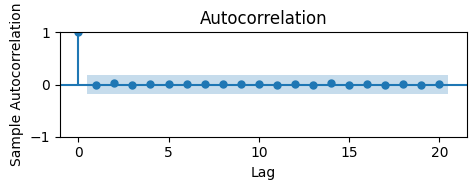

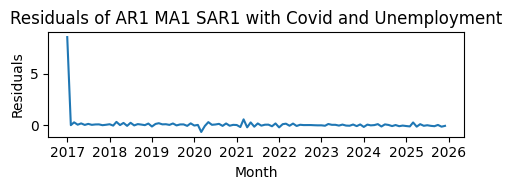

In [253]:
sarima_model_t = SARIMAX(no_of_incidents, order=(1, 0, 1), trend='t', exog = exog_vars, seasonal_order=(1, 0, 0, 12)).fit()

print(sarima_model_t.summary().tables[1])

ar_roots = sarima_model_t.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 

ma_roots = sarima_model_t.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) 

#| fig-cap: "Sample Autocorrelation function plot of ar1sar1 residuals"
fig, ax = plt.subplots(figsize=(5, 2))
plot_acf(sarima_model_t.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5, 2))
plt.title("Residuals of AR1 MA1 SAR1 with Covid and Unemployment")
plt.plot(crime_monthly['Month'], sarima_model_t.resid, '-')
plt.xlabel('Month')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

Covid only:

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
drift           -0.0002      0.000     -1.240      0.215      -0.000    9.58e-05
covid_during    -0.1071      0.028     -3.858      0.000      -0.161      -0.053
covid_post      -0.1353      0.049     -2.768      0.006      -0.231      -0.039
ar.L1            0.9887      0.005    208.344      0.000       0.979       0.998
ma.L1            0.1793      0.087      2.066      0.039       0.009       0.349
ar.S.L12         0.8475      0.057     14.834      0.000       0.736       0.960
sigma2           0.0043      0.001      7.282      0.000       0.003       0.005
Magnitude of AR roots: [1.01387965 1.01387965 1.01387965 1.01387965 1.01387965 1.01387965
 1.01387965 1.01387965 1.01387965 1.01387965 1.01387965 1.01146024
 1.01387965]
Magnitude of MA roots: [5.57698619]


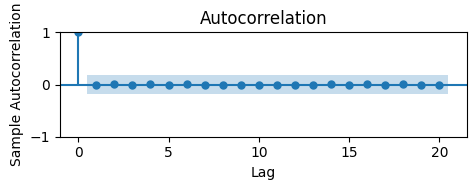

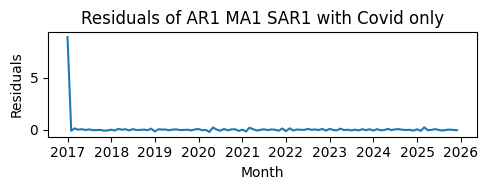

In [254]:
sarima_model_t_covid = SARIMAX(no_of_incidents, order=(1, 0, 1), trend='t', exog = exog_covid, seasonal_order=(1, 0, 0, 12)).fit()

print(sarima_model_t_covid.summary().tables[1])

ar_roots = sarima_model_t_covid.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 

ma_roots = sarima_model_t_covid.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) 

#| fig-cap: "Sample Autocorrelation function plot of ar1sar1 residuals"
fig, ax = plt.subplots(figsize=(5, 2))
plot_acf(sarima_model_t_covid.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5, 2))
plt.title("Residuals of AR1 MA1 SAR1 with Covid only")
plt.plot(crime_monthly['Month'], sarima_model_t_covid.resid, '-')
plt.xlabel('Month')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

Comparison of residuals

In [261]:
# sarima_model_t = our main model
# sarima_model_t_covid = nested model with only covid

# Identifying artifacts in model
residualsdf = pd.DataFrame({'Month': (crime_monthly['Month']).reset_index(drop=True), 'Residual':(sarima_model_t.resid).reset_index(drop=True)})
residualsdf.loc[residualsdf['Residual'].abs().nlargest(3).index]
resid_shifted = sarima_model_t.resid[1:] # removing the artifact (initial value)
print(residualsdf.loc[residualsdf['Residual'].abs().nlargest(3).index])

        Month  Residual
0  2017-01-01  8.529343
38 2020-03-01 -0.666114
50 2021-03-01  0.557037


In [262]:
# Identifying artifacts in model with only covid
residualsdf_covid = pd.DataFrame({'Month': (crime_monthly['Month']).reset_index(drop=True), 'Residual':(sarima_model_t_covid.resid).reset_index(drop=True)})
resid_shifted_t_covid = sarima_model_t_covid.resid[1:] # removing the artifact (initial value)
sarima_model_t_covid.resid.sort_values().tail()

print(residualsdf_covid.loc[residualsdf_covid['Residual'].abs().nlargest(3).index])

        Month  Residual
0  2017-01-01  8.859329
98 2025-03-01  0.250521
40 2020-05-01  0.241704


Main model with both covid and unemployment

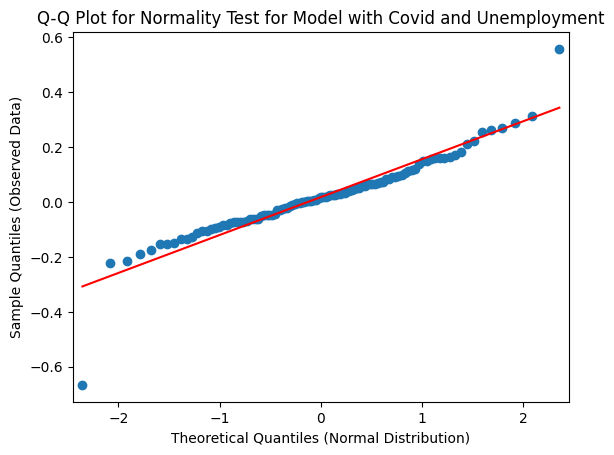

In [263]:
sm.qqplot(resid_shifted, line = 's')
plt.title('Q-Q Plot for Normality Test for Model with Covid and Unemployment')
plt.xlabel('Theoretical Quantiles (Normal Distribution)')
plt.ylabel('Sample Quantiles (Observed Data)')
plt.show()

Model with covid only

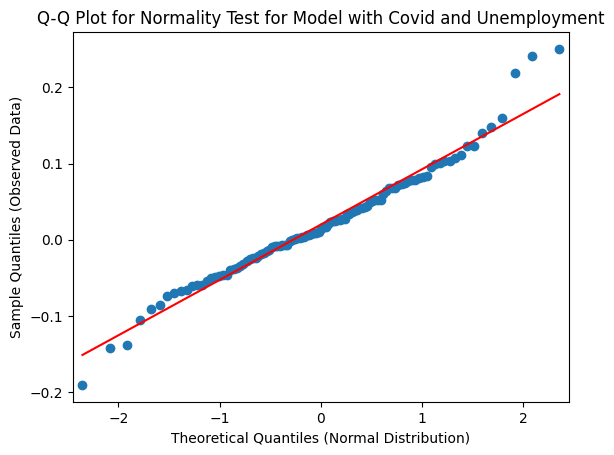

In [264]:
sm.qqplot(resid_shifted_t_covid, line = 's')
plt.title('Q-Q Plot for Normality Test for Model with Covid and Unemployment')
plt.xlabel('Theoretical Quantiles (Normal Distribution)')
plt.ylabel('Sample Quantiles (Observed Data)')
plt.show()